Эксперимент запущен. Усреднение по 5 итерациям.

Тестирование типа данных: случайные
         n |   QuickSort (с) | QuickSelect (с)
---------------------------------------------
      1000 |        0.000548 |        0.000099
      5000 |        0.003442 |        0.000427
     10000 |        0.007182 |        0.000890
     50000 |        0.040836 |        0.005781

Тестирование типа данных: отсортированные
         n |   QuickSort (с) | QuickSelect (с)
---------------------------------------------
      1000 |        0.000535 |        0.000119
      5000 |        0.003030 |        0.000404
     10000 |        0.006642 |        0.000802
     50000 |        0.037326 |        0.004824

Тестирование типа данных: обратные
         n |   QuickSort (с) | QuickSelect (с)
---------------------------------------------
      1000 |        0.000539 |        0.000131
      5000 |        0.003148 |        0.000323
     10000 |        0.006571 |        0.001031
     50000 |        0.038865 |        0.

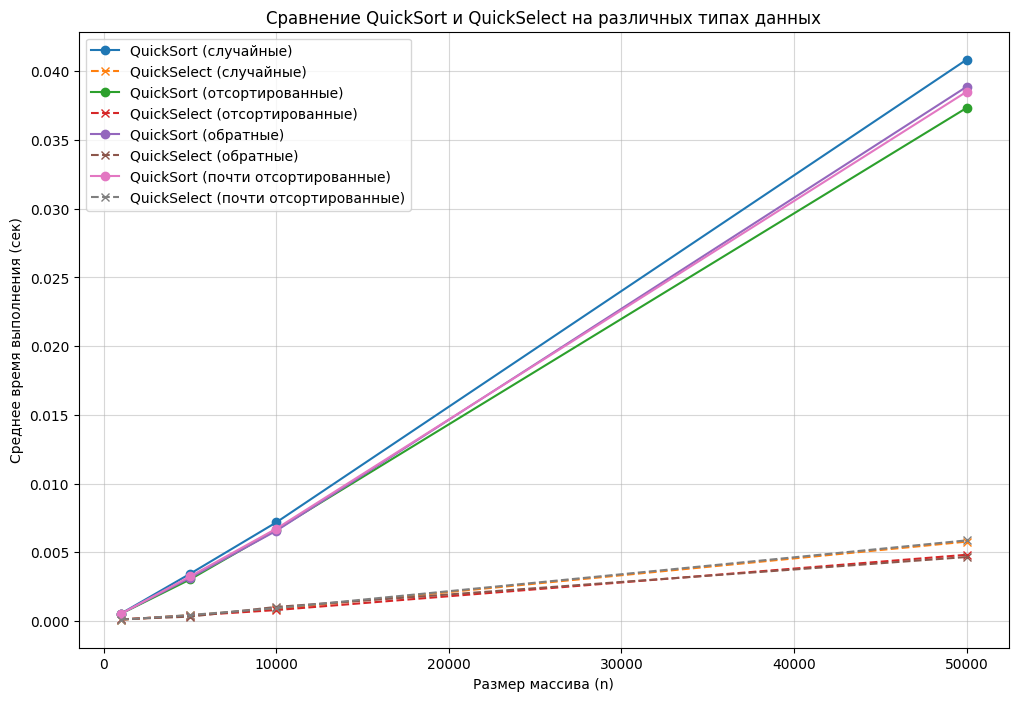

In [ ]:
import time
import random
import matplotlib.pyplot as plt
import sys

# 1. НАСТРОЙКА СИСТЕМЫ
# Для массива в 50 000 элементов на "плохих" данных рекурсия может быть глубокой.
sys.setrecursionlimit(200000)

# РЕАЛИЗАЦИЯ АЛГОРИТМОВ

def partition(arr, low, high):
    """Схема Ломуто с рандомизацией опорного элемента."""
    rand_index = random.randint(low, high)
    arr[high], arr[rand_index] = arr[rand_index], arr[high]
    
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

def quick_sort(arr, low, high):
    """Быстрая сортировка O(n log n)."""
    if low < high:
        p_index = partition(arr, low, high)
        quick_sort(arr, low, p_index - 1)
        quick_sort(arr, p_index + 1, high)

def quick_select(arr, low, high, k):
    """Быстрый поиск k-й порядковой статистики O(n)."""
    if low == high:
        return arr[low]
    pivot_index = partition(arr, low, high)
    if k == pivot_index:
        return arr[k]
    elif k < pivot_index:
        return quick_select(arr, low, pivot_index - 1, k)
    else:
        return quick_select(arr, pivot_index + 1, high, k)

# 3. ГЕНЕРАТОРЫ ДАННЫХ

def get_data(size, data_type):
    """Генерирует массив заданного типа."""
    if data_type == "случайные":
        return [random.randint(0, 1000000) for _ in range(size)]
    elif data_type == "отсортированные":
        return sorted([random.randint(0, 1000000) for _ in range(size)])
    elif data_type == "обратные":
        return sorted([random.randint(0, 1000000) for _ in range(size)], reverse=True)
    elif data_type == "почти отсортированные":
        arr = sorted([random.randint(0, 1000000) for _ in range(size)])
        # Меняем 5% элементов местами
        for _ in range(size // 20):
            i, j = random.randint(0, size-1), random.randint(0, size-1)
            arr[i], arr[j] = arr[j], arr[i]
        return arr

# ЭМПИРИЧЕСКИЙ АНАЛИЗ

def run_experiments():
    # Размеры: 10^3, 5*10^3, 10^4, 5*10^4
    sizes = [1000, 5000, 10000, 50000]
    data_types = ["случайные", "отсортированные", "обратные", "почти отсортированные"]
    iterations = 5 # Усреднение

    # Словари для хранения результатов
    results_qs = {dt: [] for dt in data_types}
    results_sel = {dt: [] for dt in data_types}

    print(f"Эксперимент запущен. Усреднение по {iterations} итерациям.")
    
    for d_type in data_types:
        print(f"\nТестирование типа данных: {d_type}")
        print(f"{'n':>10} | {'QuickSort (с)':>15} | {'QuickSelect (с)':>15}")
        print("-" * 45)
        
        for n in sizes:
            qs_sum = 0
            sel_sum = 0
            
            for _ in range(iterations):
                base_arr = get_data(n, d_type)
                
                # Замер QuickSort
                arr_qs = base_arr.copy()
                t0 = time.perf_counter()
                quick_sort(arr_qs, 0, n - 1)
                qs_sum += (time.perf_counter() - t0)

                # Замер QuickSelect (медиана)
                arr_sel = base_arr.copy()
                t0 = time.perf_counter()
                quick_select(arr_sel, 0, n - 1, n // 2)
                sel_sum += (time.perf_counter() - t0)

            avg_qs = qs_sum / iterations
            avg_sel = sel_sum / iterations
            
            results_qs[d_type].append(avg_qs)
            results_sel[d_type].append(avg_sel)
            
            print(f"{n:10} | {avg_qs:15.6f} | {avg_sel:15.6f}")

    # ПОСТРОЕНИЕ ГРАФИКОВ
    plt.figure(figsize=(12, 8))
    
    for d_type in data_types:
        # Линии QuickSort (сплошные)
        plt.plot(sizes, results_qs[d_type], label=f'QuickSort ({d_type})', marker='o')
        # Линии QuickSelect (пунктирные)
        plt.plot(sizes, results_sel[d_type], label=f'QuickSelect ({d_type})', marker='x', linestyle='--')

    plt.title('Сравнение QuickSort и QuickSelect на различных типах данных')
    plt.xlabel('Размер массива (n)')
    plt.ylabel('Среднее время выполнения (сек)')
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.5)
    
    plt.savefig('analysis.png', dpi=300)
    print("\nГрафик 'analysis' сформирован.")
    plt.show()

if __name__ == "__main__":
    run_experiments()